<a href="https://colab.research.google.com/github/Savindi2002/CV-Analyzer-Job-Matching/blob/main/CV_Analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn nltk beautifulsoup4 sentence-transformers transformers torch

In [ ]:
import pandas as pd
import numpy as np
import re
import os
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns

from bs4 import BeautifulSoup

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer

import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
resume_path = "/content/drive/MyDrive/NLP Project/Resume.csv"
job_path = "/content/drive/MyDrive/NLP Project/data.csv"

In [ ]:
resume_df = pd.read_csv(resume_path)
job_df = pd.read_csv(job_path)

In [ ]:
print("Resume Dataset:")
print(resume_df.shape)

print("\nJob Dataset:")
print(job_df.shape)

Resume Dataset:
(2484, 4)

Job Dataset:
(521, 2)


In [ ]:
print("Resume columns:")
print(resume_df.columns.tolist())

print("\nJob columns:")
print(job_df.columns.tolist())

Resume columns:
['ID', 'Resume_str', 'Resume_html', 'Category']

Job columns:
['Job Title', 'Description']


In [ ]:
resume_df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [ ]:
job_df.head()

,Job Title,Description
0,Data Analyst,job overview were seeking a data analyst to tu...
1,Data Reporting Analyst,about wspc wspc is a cooperative of outstandin...
2,Data Analyst (Power BI/Python),data analyst power bipython employment type fu...
3,Data & Reporting Analyst,our company pharmerica overview the data repor...
4,Data Quality Analyst (Remote Opportunity),vetsez is seeking a data quality analyst teste...


In [ ]:
print("Resume missing values:")
print(resume_df.isnull().sum())

print("\nJob missing values:")
print(job_df.isnull().sum())

Resume missing values:
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

Job missing values:
Job Title      0
Description    0
dtype: int64


In [ ]:
print("Duplicate resumes:", resume_df.duplicated().sum())
print("Duplicate jobs:", job_df.duplicated().sum())

Duplicate resumes: 0
Duplicate jobs: 0


In [ ]:
resume_df = resume_df.drop_duplicates()
job_df = job_df.drop_duplicates()

In [ ]:
print(resume_df.columns.tolist())

['ID', 'Resume_str', 'Resume_html', 'Category']


In [ ]:
resume_df = resume_df[['ID', 'Resume_str', 'Category']]

resume_df.head()
resume_df.tail()

,ID,Resume_str,Category
2479,99416532,RANK: SGT/E-5 NON- COMMISSIONED OFFIC...,AVIATION
2480,24589765,"GOVERNMENT RELATIONS, COMMUNICATIONS ...",AVIATION
2481,31605080,GEEK SQUAD AGENT Professional...,AVIATION
2482,21190805,PROGRAM DIRECTOR / OFFICE MANAGER ...,AVIATION
2483,37473139,STOREKEEPER II Professional Sum...,AVIATION


In [ ]:
resume_df = resume_df.rename(columns={
    'ID': 'resume_id',
    'Resume_str': 'resume_text',
    'Category': 'category'
})

job_df = job_df.rename(columns={
    'Job Title': 'job_title',
    'Description': 'job_description'
})

In [ ]:
print(resume_df.columns)
print(job_df.columns)

Index(['resume_id', 'resume_text', 'category'], dtype='object')
Index(['job_title', 'job_description'], dtype='object')


In [ ]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text)

    # Remove HTML
    text = BeautifulSoup(text, "html.parser").get_text()

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove special characters
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
resume_df['clean_resume'] = resume_df['resume_text'].apply(clean_text)

job_df['clean_job'] = job_df['job_description'].apply(clean_text)

In [ ]:
print("BEFORE:")
print(resume_df['resume_text'].iloc[0][:1000])

print("\n\nAFTER:")
print(resume_df['clean_resume'].iloc[0][:1000])

BEFORE:
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies, inventory control, lo

In [ ]:
sample_text = resume_df['clean_resume'].iloc[0]

tokens = sample_text.split()

print(tokens[:30])

['hr', 'administrator', 'marketing', 'associate', 'hr', 'administrator', 'summary', 'dedicated', 'customer', 'service', 'manager', 'with', '15', 'years', 'of', 'experience', 'in', 'hospitality', 'and', 'customer', 'service', 'management', 'respected', 'builder', 'and', 'leader', 'of', 'customer', 'focused', 'teams']


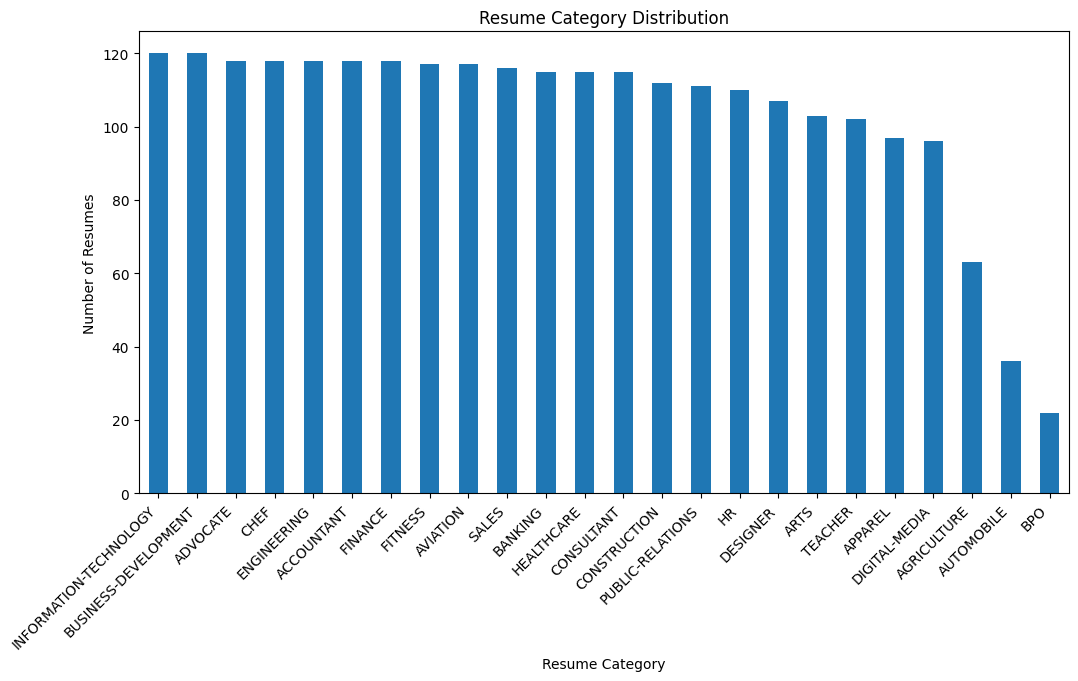

In [ ]:
plt.figure(figsize=(12, 6))

resume_df['category'].value_counts().plot(kind='bar')

plt.title('Resume Category Distribution')
plt.xlabel('Resume Category')
plt.ylabel('Number of Resumes')
plt.xticks(rotation=45, ha='right')

plt.show()

In [ ]:
category_counts = resume_df['category'].value_counts()

print(category_counts)

category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


In [ ]:
print("Number of categories:", resume_df['category'].nunique())
print("Largest class:", category_counts.max())
print("Smallest class:", category_counts.min())

Number of categories: 24
Largest class: 120
Smallest class: 22


In [ ]:
category_percentage = (
    resume_df['category']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(category_percentage)

category
INFORMATION-TECHNOLOGY    4.83
BUSINESS-DEVELOPMENT      4.83
ADVOCATE                  4.75
CHEF                      4.75
ENGINEERING               4.75
ACCOUNTANT                4.75
FINANCE                   4.75
FITNESS                   4.71
AVIATION                  4.71
SALES                     4.67
BANKING                   4.63
HEALTHCARE                4.63
CONSULTANT                4.63
CONSTRUCTION              4.51
PUBLIC-RELATIONS          4.47
HR                        4.43
DESIGNER                  4.31
ARTS                      4.15
TEACHER                   4.11
APPAREL                   3.90
DIGITAL-MEDIA             3.86
AGRICULTURE               2.54
AUTOMOBILE                1.45
BPO                       0.89
Name: proportion, dtype: float64


In [ ]:
from collections import Counter

all_resume_words = ' '.join(
    resume_df['clean_resume']
).split()

word_counts = Counter(all_resume_words)

print(word_counts.most_common(30))

[('and', 123591), ('to', 54659), ('of', 43331), ('the', 37016), ('in', 28483), ('for', 28445), ('with', 21669), ('a', 17223), ('state', 16156), ('company', 15212), ('city', 15077), ('management', 12174), ('name', 11739), ('on', 11036), ('as', 10630), ('all', 8689), ('sales', 8275), ('customer', 7927), ('business', 7866), ('skills', 7729), ('by', 6775), ('new', 6407), ('s', 6238), ('service', 6223), ('team', 6073), ('development', 5731), ('training', 5637), ('experience', 5632), ('project', 5362), ('i', 4901)]


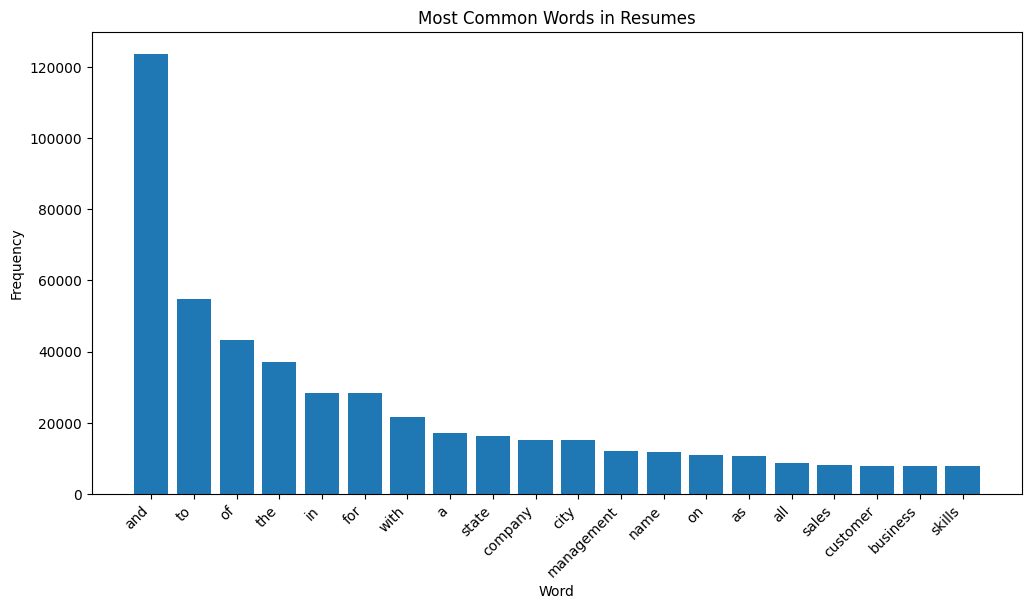

In [ ]:
common_words = word_counts.most_common(20)

words = [item[0] for item in common_words]
counts = [item[1] for item in common_words]

plt.figure(figsize=(12, 6))

plt.bar(words, counts)

plt.title('Most Common Words in Resumes')
plt.xlabel('Word')
plt.ylabel('Frequency')

plt.xticks(rotation=45, ha='right')

plt.show()

In [ ]:
resume_df['resume_length'] = resume_df['clean_resume'].apply(
    lambda x: len(x.split())
)

In [ ]:
print(resume_df['resume_length'].describe())

count    2484.000000
mean      816.628824
std       376.576362
min         0.000000
25%       654.000000
50%       761.000000
75%       939.250000
max      5175.000000
Name: resume_length, dtype: float64


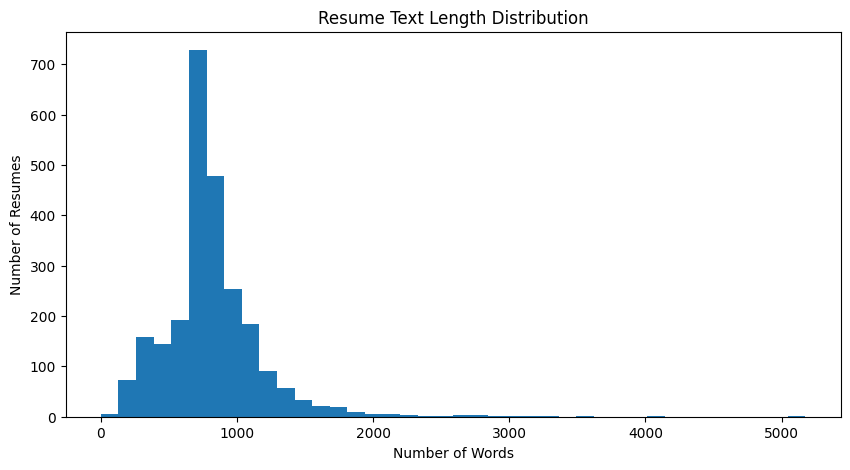

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(
    resume_df['resume_length'],
    bins=40
)

plt.title('Resume Text Length Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Number of Resumes')

plt.show()

In [ ]:
job_df['job_length'] = job_df['clean_job'].apply(
    lambda x: len(x.split())
)

In [ ]:
print(job_df['job_length'].describe())

count     521.000000
mean      653.301344
std       303.217888
min         1.000000
25%       436.000000
50%       642.000000
75%       840.000000
max      2160.000000
Name: job_length, dtype: float64


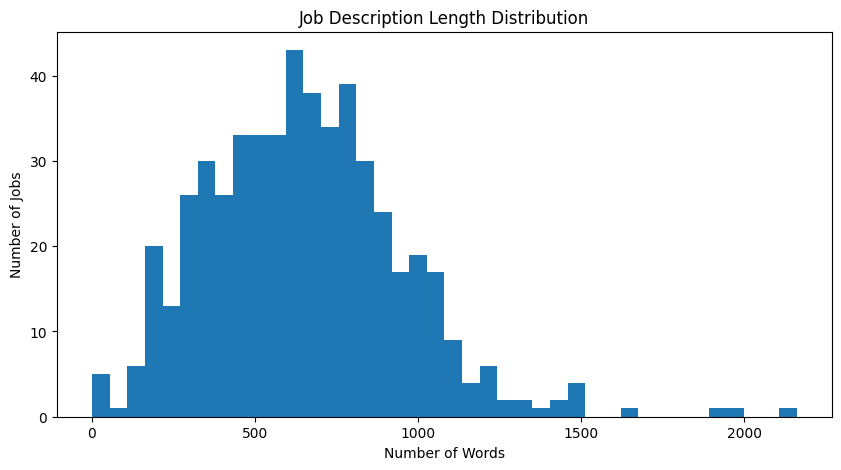

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(
    job_df['job_length'],
    bins=40
)

plt.title('Job Description Length Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Number of Jobs')

plt.show()

In [ ]:
!pip install -q wordcloud

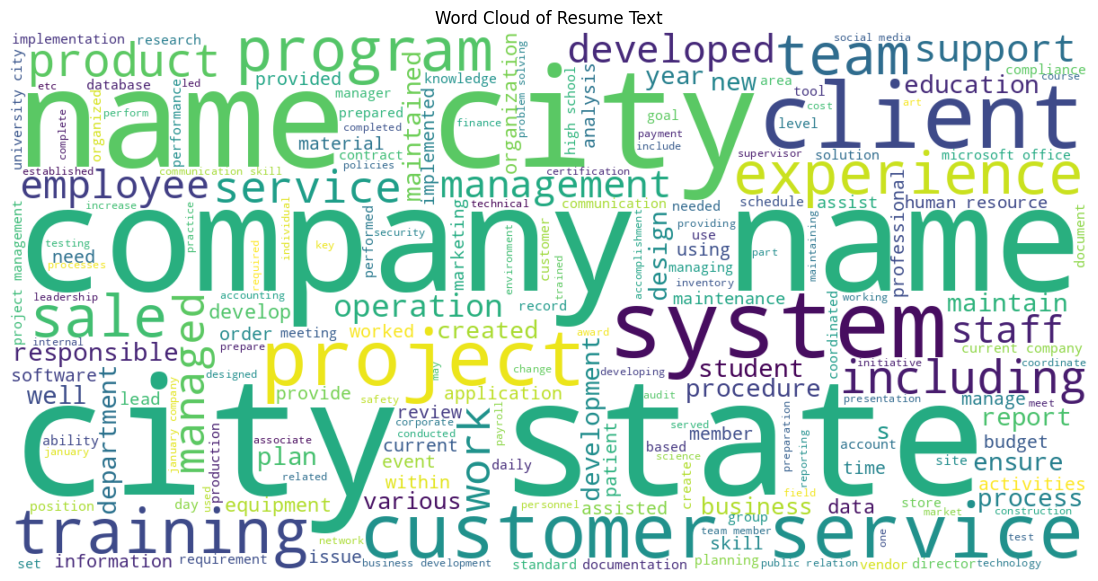

In [ ]:
from wordcloud import WordCloud

resume_text = ' '.join(
    resume_df['clean_resume']
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white'
).generate(resume_text)

plt.figure(figsize=(15, 7))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')
plt.title('Word Cloud of Resume Text')

plt.show()

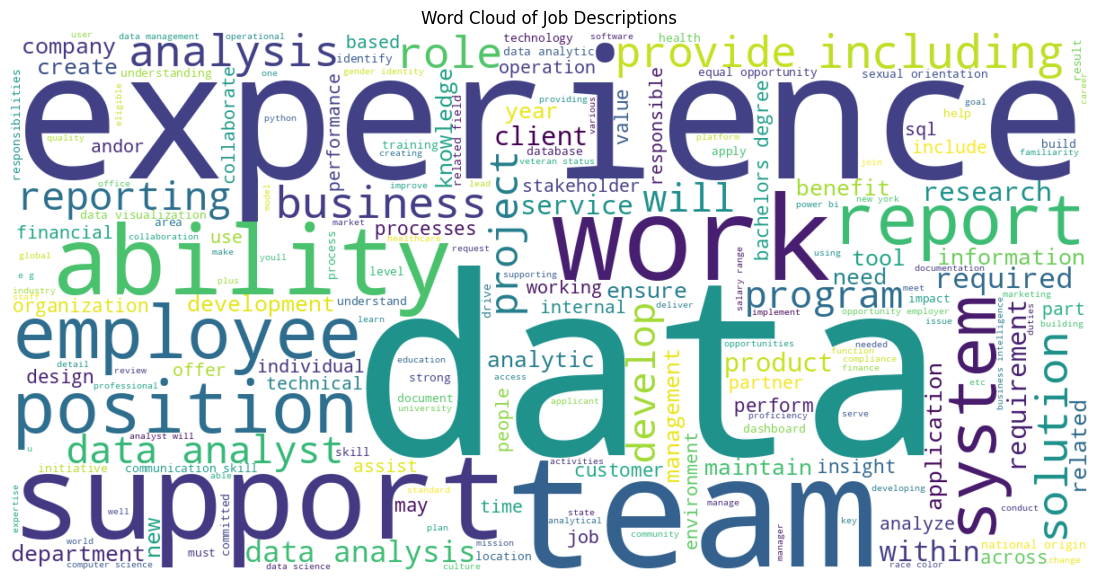

In [ ]:
job_text = ' '.join(
    job_df['clean_job']
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white'
).generate(job_text)

plt.figure(figsize=(15, 7))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')
plt.title('Word Cloud of Job Descriptions')

plt.show()

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer(
    max_features=5000,
    stop_words='english'
)

bow_matrix = bow_vectorizer.fit_transform(
    resume_df['clean_resume']
)

print("BoW matrix shape:", bow_matrix.shape)

BoW matrix shape: (2484, 5000)


In [ ]:
print(
    bow_vectorizer.get_feature_names_out()[:30]
)

['00' '000' '01' '02' '03' '04' '05' '06' '07' '08' '09' '10' '100' '1000'
 '101' '1099' '10g' '11' '110' '11g' '12' '120' '125' '13' '14' '15' '150'
 '16' '17' '18']


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words='english'
)

X_tfidf = tfidf_vectorizer.fit_transform(
    resume_df['clean_resume']
)

print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (2484, 10000)


In [ ]:
y = resume_df['category']

In [ ]:
print(y.head())

0    HR
1    HR
2    HR
3    HR
4    HR
Name: category, dtype: object


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1987
Testing samples: 497


In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000
)

logistic_model.fit(
    X_train,
    y_train
)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred_logistic = logistic_model.predict(X_test)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

logistic_precision = precision_score(
    y_test,
    y_pred_logistic,
    average='weighted'
)

logistic_recall = recall_score(
    y_test,
    y_pred_logistic,
    average='weighted'
)

logistic_f1 = f1_score(
    y_test,
    y_pred_logistic,
    average='weighted'
)

print("Logistic Regression")
print("--------------------")
print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall   :", logistic_recall)
print("F1 Score :", logistic_f1)

Logistic Regression
--------------------
Accuracy : 0.647887323943662
Precision: 0.6617674996902241
Recall   : 0.647887323943662
F1 Score : 0.6320515779288972


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print(
    classification_report(
        y_test,
        y_pred_logistic
    )
)

                        precision    recall  f1-score   support

            ACCOUNTANT       0.65      0.83      0.73        24
              ADVOCATE       0.36      0.54      0.43        24
           AGRICULTURE       1.00      0.38      0.56        13
               APPAREL       0.67      0.21      0.32        19
                  ARTS       0.46      0.29      0.35        21
            AUTOMOBILE       0.00      0.00      0.00         7
              AVIATION       0.81      0.71      0.76        24
               BANKING       0.83      0.65      0.73        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.46      0.79      0.58        24
                  CHEF       0.81      0.71      0.76        24
          CONSTRUCTION       0.82      0.82      0.82        22
            CONSULTANT       0.50      0.17      0.26        23
              DESIGNER       0.84      0.76      0.80        21
         DIGITAL-MEDIA       0.71      

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(
    X_train,
    y_train
)

LinearSVC()

In [ ]:
y_pred_svm = svm_model.predict(X_test)

In [ ]:
svm_accuracy = accuracy_score(
    y_test,
    y_pred_svm
)

svm_precision = precision_score(
    y_test,
    y_pred_svm,
    average='weighted'
)

svm_recall = recall_score(
    y_test,
    y_pred_svm,
    average='weighted'
)

svm_f1 = f1_score(
    y_test,
    y_pred_svm,
    average='weighted'
)

print("SVM")
print("--------------------")
print("Accuracy :", svm_accuracy)
print("Precision:", svm_precision)
print("Recall   :", svm_recall)
print("F1 Score :", svm_f1)

SVM
--------------------
Accuracy : 0.704225352112676
Precision: 0.7118812824070174
Recall   : 0.704225352112676
F1 Score : 0.6911633845715401


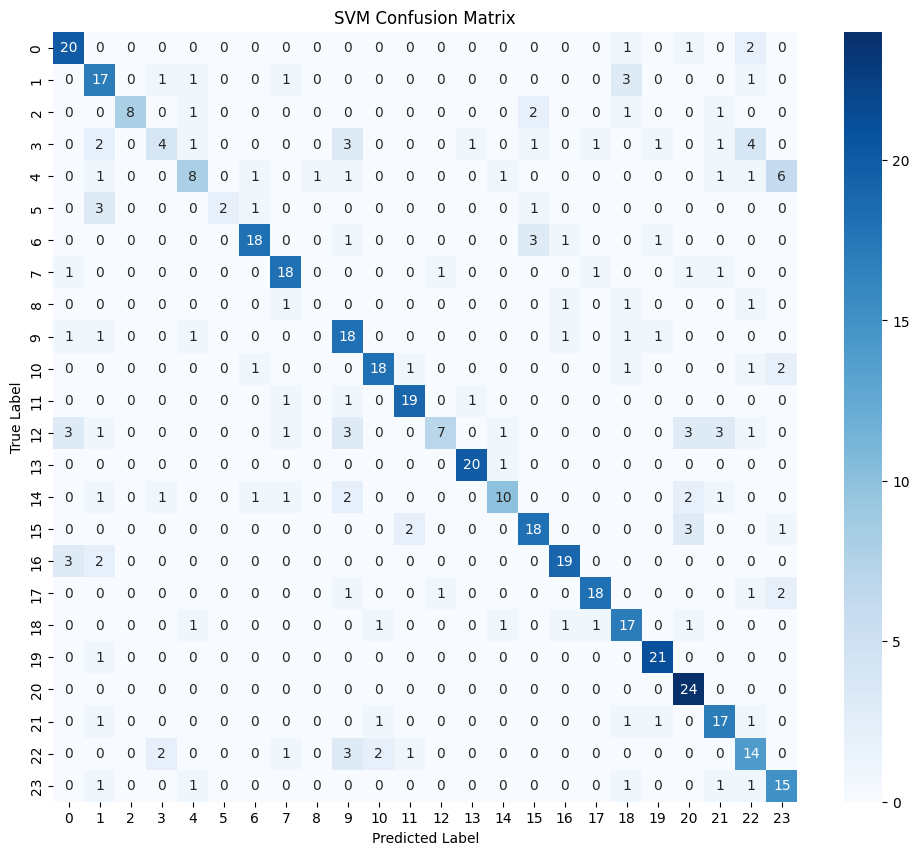

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_svm
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'SVM'
    ],

    'Accuracy': [
        logistic_accuracy,
        svm_accuracy
    ],

    'Precision': [
        logistic_precision,
        svm_precision
    ],

    'Recall': [
        logistic_recall,
        svm_recall
    ],

    'F1 Score': [
        logistic_f1,
        svm_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.647887,0.661767,0.647887,0.632052
1,SVM,0.704225,0.711881,0.704225,0.691163


In [ ]:
!pip install -q sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer

In [ ]:
transformer_model = SentenceTransformer(
    'all-MiniLM-L6-v2'
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [60]:
X_transformer = transformer_model.encode(
    resume_df['clean_resume'].tolist(),
    show_progress_bar=True
)

print("Transformer embedding shape:")
print(X_transformer.shape)

Batches:   0%|          | 0/78 [00:00<?, ?it/s]

Transformer embedding shape:
(2484, 384)


In [61]:
indices = np.arange(len(resume_df))

train_indices, test_indices = train_test_split(
    indices,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [62]:
X_train_transformer = X_transformer[train_indices]
X_test_transformer = X_transformer[test_indices]

y_train_transformer = y.iloc[train_indices]
y_test_transformer = y.iloc[test_indices]

In [63]:
transformer_classifier = LogisticRegression(
    max_iter=1000
)

transformer_classifier.fit(
    X_train_transformer,
    y_train_transformer
)

LogisticRegression(max_iter=1000)